# Set-up
## Author: Michael Chen (mwc2150@columbia.edu)

In [4]:
# enviro setup
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
import numpy as np
import scipy as sp

%pip install category_encoders
%pip install xgboost
%pip install lightgbm

# show all rows
pd.set_option('display.max_columns', None)

SEED = 0

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Introduction: problem definition + dataset description.

Product Curation / Inventory Decisions: "Given only information available at the pre-sale phase, how likely will a product in our inventory be recommended by our customers?"
- Dependent variable: The name of products that we should include in our kits, measured by customer reccomendation likelihood. This is critical because we only have so much starting capital to work with, and we must find the best way to bundle our stock inventory of skincare/journals/etc. such that consumers in the West LA region will be keen to purchase our wares (pre-launch filter). 
- Analytical constraints: The analysis is limited to information that is available to us at launch: this means brand rep, price tier, target demographic information. Any post-sale feature like product reviews or even the product name (our resulting/confounding variable) itself will have to be excluded from our analysis. We also have no real baseline or past approaches to work from so we will have to create one, and stick to a set of metrics to measure improvements against.
- Trade-offs: The end user benefit is that customers receive a product they actually will use and want rather than something they buy out of impulse, guilt, or otherwise frivolous reasons. If an incorrest decision is made here, the risk for Rexi is questionable since we are indeed using the results of this analysis to inform the launch of our first product of the sort. The worst outcome is that a wrong reccomendation leads to a dissatisfied customer and a poor review, which can be devastating for a startup of our size. However, at the end of the day this what I am tasked to do, and the decision comes down to if our ML results here align with our founder's domain knowledge on holistic wellness.  

Dataset Description: The Sephora dataset is a Kaggle collection of customer reviews merged with product metadata from Sephora's online catalog, spanning hundreds of thousands of reviews across thousands of SKUs. 
- The reviews table captures reviewer demographics (skin type, skin tone, hair color, eye color), a 1–5 star rating, and a binary is_recommended flag, while the product table adds brand, price, aggregate rating, and category attributes. 
- The two tables join on product_id, producing roughly 43 features after merging. The target variable is_recommended is severely imbalanced, with the vast majority of reviews being positive recommendations.
- It is acknowledged that this is not a 

In [38]:
df_products = pd.read_csv('data\product_info.csv')
df_products

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,NaN,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8489,P467659,Couture Clutch Eyeshadow Palette,1070,Yves Saint Laurent,2790,4.4286,7.0,NaN,NaN,NaN,NaN,"['Talc, Synthetic Fluorphlogopite, Triethylhex...",150.0,NaN,NaN,0,0,0,0,0,NaN,Makeup,Eye,Eye Palettes,0,NaN,NaN
8490,P500874,L'Homme Eau de Parfum,1070,Yves Saint Laurent,2319,4.6367,556.0,2 oz / 60 mL,Size + Concentration + Formulation,2 oz / 60 mL eau de parfum spray,NaN,"['Alcohol, Aqua / Water / Eau, Parfum / Fragra...",106.0,NaN,NaN,0,0,0,0,0,"['Layerable Scent', 'Woody & Earthy Scent']",Fragrance,Men,Cologne,1,129.0,129.0
8491,P504428,Mon Paris Eau de Parfum Gift Set,1070,Yves Saint Laurent,1475,5.0000,2.0,NaN,NaN,NaN,NaN,"['Mon Paris Eau de Parfum:', 'Alcohol, Parfum/...",134.0,179.0,NaN,1,1,1,1,0,NaN,Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
8492,P504448,Y Eau de Parfum Gift Set,1070,Yves Saint Laurent,840,NaN,NaN,NaN,NaN,NaN,NaN,"['Alcohol, Parfum/Fragrance, Aqua/Water, Limon...",167.0,199.0,NaN,1,1,1,0,0,NaN,Fragrance,Value & Gift Sets,Cologne Gift Sets,0,NaN,NaN


In [6]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   object 
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   object 
 8   variation_type      7050 non-null   object 
 9   variation_value     6896 non-null   object 
 10  variation_desc      1250 non-null   object 
 11  ingredients         7549 non-null   object 
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition     8494 non-null   int64  
 16  new   

In [42]:
reviews_part1 = pd.read_csv('data/reviews_0-250.csv')
reviews_part1

C:\Users\micha\AppData\Local\Temp\ipykernel_20404\729246125.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_part1 = pd.read_csv('data/reviews_0-250.csv')


,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
602125,602125,7446977307,5,1.0,1.0,12,0,12,2020-12-17,I can’t say enough great things about this pro...,HOLY GRAIL- lash extension safe!!,fair,green,dry,blonde,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,68.0
602126,602126,1991973234,5,1.0,1.0,4,0,4,2020-12-17,I have been using this product for over 6 week...,Game changer!,mediumTan,brown,combination,black,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,68.0
602127,602127,1339171721,5,1.0,1.0,10,0,10,2020-12-17,I love the Triple Algae Eye Renewal Balm! Once...,Triple Algae Eye Renewal Balm is a MUST HAVE,light,hazel,dry,brown,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,68.0
602128,602128,1917233409,5,1.0,1.0,5,0,5,2020-12-17,This made the lines around my eyes so much bet...,NaN,lightMedium,hazel,combination,brown,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,68.0


In [43]:
reviews_part2 = pd.read_csv('data/reviews_250-500.csv')
reviews_part2   

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,2190293206,2,0.0,NaN,0,0,0,2023-03-19,Used to swear by this product but hate the sme...,NaN,lightMedium,brown,combination,brown,P443842,Retinol Anti-Aging Serum,The INKEY List,12.99
1,1,9113341005,5,1.0,NaN,0,0,0,2023-03-18,I’ve only been using this for a week and my sk...,More tolerable than The Ordinary,deep,brown,normal,black,P443842,Retinol Anti-Aging Serum,The INKEY List,12.99
2,2,23866342710,1,0.0,1.000000,13,0,13,2023-03-12,"Why, why, why would you change the formula?!!!...",New formula is awful very sad,fairLight,blue,combination,blonde,P443842,Retinol Anti-Aging Serum,The INKEY List,12.99
3,3,1328806527,1,0.0,0.941176,17,1,16,2023-03-12,I have used this product for years and it has ...,Recently reformulated and the new formula is A...,light,brown,combination,gray,P443842,Retinol Anti-Aging Serum,The INKEY List,12.99
4,4,31262847082,5,1.0,1.000000,1,0,1,2023-03-09,Great product for anti-aging Also great for da...,Must have product in my nighttime skincare rou...,lightMedium,hazel,combination,brown,P443842,Retinol Anti-Aging Serum,The INKEY List,12.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206720,206720,5113824372,4,1.0,0.851852,27,4,23,2019-05-02,I haven’t used this long enough to report any ...,NaN,mediumTan,brown,normal,black,P443846,Collagen Booster Firming Peptide Serum,The INKEY List,12.99
206721,206721,5297430713,5,1.0,0.750000,32,8,24,2019-04-27,"this serum is GREAT! Absorbs nicely, sits well...",NaN,medium,brown,dry,black,P443846,Collagen Booster Firming Peptide Serum,The INKEY List,12.99
206722,206722,2090479401,5,1.0,0.736842,38,10,28,2019-04-22,I have been using this serum on my neck (day a...,Nice Collagen Serum!,fairLight,blue,dry,blonde,P443846,Collagen Booster Firming Peptide Serum,The INKEY List,12.99
206723,206723,10575410512,4,1.0,0.795455,44,9,35,2019-04-19,I enjoyed this product more as a “primer” for ...,Great as a primer!,light,blue,combination,brown,P443846,Collagen Booster Firming Peptide Serum,The INKEY List,12.99


In [44]:
reviews_part3 = pd.read_csv('data/reviews_500-750.csv')
reviews_part3

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,2079014373,5,1.0,NaN,0,0,0,2023-03-14,These are the only pimple patches I’ve used th...,Best Pimple Patches,medium,blue,normal,NaN,P442857,Focuspot Micro Tip Patches,Dr. Jart+,20.0
1,1,12631885517,4,1.0,NaN,0,0,0,2023-02-08,One of my ingrown hair turned inflamed and sor...,It works!,mediumTan,brown,combination,black,P442857,Focuspot Micro Tip Patches,Dr. Jart+,20.0
2,2,2321761961,5,1.0,1.0,1,0,1,2023-02-05,I have tried 10 different acne/blemish patches...,Good for a large or painful breakout! Sleep in...,NaN,hazel,combination,blonde,P442857,Focuspot Micro Tip Patches,Dr. Jart+,20.0
3,3,1380382883,4,1.0,NaN,0,0,0,2023-01-24,"Love these for my mid-size breakouts, specifyi...",Micro tips are a plus!!,light,brown,combination,black,P442857,Focuspot Micro Tip Patches,Dr. Jart+,20.0
4,4,8871759068,4,1.0,1.0,1,0,1,2023-01-15,Best so far - though still not particularly ef...,NaN,NaN,NaN,NaN,NaN,P442857,Focuspot Micro Tip Patches,Dr. Jart+,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116257,116257,7549964033,3,0.0,1.0,2,0,2,2022-11-24,"Cute packaging, innovative component. The prod...",Can live without it,NaN,brown,oily,NaN,P503692,Plush Puddin’ Intensive Recovery Lip Mask With...,Fenty Skin,22.0
116258,116258,22017857232,5,1.0,1.0,1,0,1,2022-11-24,"I am obsessed with this intensive lip mask, do...",Loveeee!,fair,brown,dry,black,P503692,Plush Puddin’ Intensive Recovery Lip Mask With...,Fenty Skin,22.0
116259,116259,30329641422,5,1.0,NaN,0,0,0,2022-11-24,After using this product from a free sample pr...,Best Lip Mask Ever!,lightMedium,blue,normal,blonde,P503692,Plush Puddin’ Intensive Recovery Lip Mask With...,Fenty Skin,22.0
116260,116260,34099439981,5,1.0,NaN,0,0,0,2022-11-24,Plum and plush my lips are. These don’t necess...,Plush pudding makes me lips look so smooth,NaN,brown,combination,black,P503692,Plush Puddin’ Intensive Recovery Lip Mask With...,Fenty Skin,22.0


In [45]:
reviews_part4 = pd.read_csv('data/reviews_750-1250.csv')
reviews_part4   

C:\Users\micha\AppData\Local\Temp\ipykernel_20404\3584961239.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_part4 = pd.read_csv('data/reviews_750-1250.csv')


,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,8554483509,2,0.0,NaN,0,0,0,2023-03-21,This was gifted by Supergoop! in exchange for ...,Nice packaging but easy to overuse,light,brown,combination,NaN,P467976,(Re)setting 100% Mineral Powder Sunscreen SPF ...,Supergoop!,35.0
1,1,24710523057,2,0.0,1.000000,2,0,2,2023-03-07,I didn’t like it; too much product comes out w...,Packaging is not suits le,NaN,brown,combination,NaN,P467976,(Re)setting 100% Mineral Powder Sunscreen SPF ...,Supergoop!,35.0
2,2,8429283179,5,1.0,0.941176,34,2,32,2023-03-01,Y’all….I’m begging for everyone to read instru...,PLS READ THIS LOL,light,green,normal,brown,P467976,(Re)setting 100% Mineral Powder Sunscreen SPF ...,Supergoop!,35.0
3,3,8105185455,1,0.0,0.000000,5,5,0,2023-02-27,I have not figured out how to use this product...,At a loss,tan,brown,combination,black,P467976,(Re)setting 100% Mineral Powder Sunscreen SPF ...,Supergoop!,35.0
4,4,1515931062,1,0.0,0.000000,7,7,0,2023-02-27,I’m at a loss as to how to use this thing!!! C...,NOT for me!!,fair,blue,combination,blonde,P467976,(Re)setting 100% Mineral Powder Sunscreen SPF ...,Supergoop!,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119312,119312,9109189891,5,1.0,NaN,0,0,0,2022-04-29,I LOVE this stuff! It works amazingly well at ...,Great product!,NaN,NaN,NaN,NaN,P500101,Hydro Ungrip Makeup Remover + Cleansing Water,MILK MAKEUP,32.0
119313,119313,8115925555,5,1.0,NaN,0,0,0,2022-04-29,love this micellar water from Milk! it removes...,NaN,medium,brown,oily,red,P500101,Hydro Ungrip Makeup Remover + Cleansing Water,MILK MAKEUP,32.0
119314,119314,10723607564,5,1.0,NaN,0,0,0,2022-04-29,I loveeeeee Milk!!! Just discovered this brand...,NaN,mediumTan,brown,dry,black,P500101,Hydro Ungrip Makeup Remover + Cleansing Water,MILK MAKEUP,32.0
119315,119315,5953458355,5,1.0,NaN,0,0,0,2022-04-29,"My new favorite makeup remover. First of all, ...",Works extremely well,light,blue,combination,blonde,P500101,Hydro Ungrip Makeup Remover + Cleansing Water,MILK MAKEUP,32.0


In [46]:
reviews_part5 = pd.read_csv('data/reviews_1250-end.csv')
reviews_part5

C:\Users\micha\AppData\Local\Temp\ipykernel_20404\2235208977.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_part5 = pd.read_csv('data/reviews_1250-end.csv')


,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1945004256,5,1.0,0.000000,2,2,0,2022-12-10,I absolutely L-O-V-E this oil. I have acne pro...,A must have!,lightMedium,green,combination,NaN,P379064,Lotus Balancing & Hydrating Natural Face Treat...,Clarins,65.0
1,1,5478482359,3,1.0,0.333333,3,2,1,2021-12-17,I gave this 3 stars because it give me tiny li...,it keeps oily skin under control,mediumTan,brown,oily,black,P379064,Lotus Balancing & Hydrating Natural Face Treat...,Clarins,65.0
2,2,29002209922,5,1.0,1.000000,2,0,2,2021-06-07,Works well as soon as I wash my face and pat d...,Worth the money!,lightMedium,brown,dry,black,P379064,Lotus Balancing & Hydrating Natural Face Treat...,Clarins,65.0
3,3,7391078463,5,1.0,1.000000,2,0,2,2021-05-21,"this oil helped with hydration and breakouts, ...",best face oil,lightMedium,brown,combination,blonde,P379064,Lotus Balancing & Hydrating Natural Face Treat...,Clarins,65.0
4,4,1766313888,5,1.0,1.000000,13,0,13,2021-03-29,This is my first product review ever so that s...,Maskne miracle,mediumTan,brown,combination,black,P379064,Lotus Balancing & Hydrating Natural Face Treat...,Clarins,65.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49972,49972,2276253200,5,1.0,NaN,0,0,0,2023-03-13,Consider salicylic acid your secret weapon for...,NaN,fair,brown,combination,NaN,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
49973,49973,28013163278,5,1.0,NaN,0,0,0,2023-03-13,I’ve been using this as my only moisturizer fo...,NaN,NaN,blue,combination,blonde,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
49974,49974,1539813076,5,1.0,NaN,0,0,0,2023-03-13,I got breakouts whenever it’s my time of month...,NaN,light,blue,combination,blonde,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
49975,49975,5595682861,5,1.0,NaN,0,0,0,2023-03-13,I love this!!! I don’t get actual acne just an...,NaN,fair,hazel,oily,NaN,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0


In [12]:
# combine all reviews into one dataframe
df_reviews = pd.concat([reviews_part1, reviews_part2, reviews_part3, reviews_part4, reviews_part5], ignore_index=True)
df_reviews

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094406,49972,2276253200,5,1.0,NaN,0,0,0,2023-03-13,Consider salicylic acid your secret weapon for...,NaN,fair,brown,combination,NaN,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
1094407,49973,28013163278,5,1.0,NaN,0,0,0,2023-03-13,I’ve been using this as my only moisturizer fo...,NaN,NaN,blue,combination,blonde,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
1094408,49974,1539813076,5,1.0,NaN,0,0,0,2023-03-13,I got breakouts whenever it’s my time of month...,NaN,light,blue,combination,blonde,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
1094409,49975,5595682861,5,1.0,NaN,0,0,0,2023-03-13,I love this!!! I don’t get actual acne just an...,NaN,fair,hazel,oily,NaN,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0


In [13]:
df_reviews.info()
# df_reviews.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094411 entries, 0 to 1094410
Data columns (total 19 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Unnamed: 0                1094411 non-null  int64  
 1   author_id                 1094411 non-null  object 
 2   rating                    1094411 non-null  int64  
 3   is_recommended            926423 non-null   float64
 4   helpfulness               532819 non-null   float64
 5   total_feedback_count      1094411 non-null  int64  
 6   total_neg_feedback_count  1094411 non-null  int64  
 7   total_pos_feedback_count  1094411 non-null  int64  
 8   submission_time           1094411 non-null  object 
 9   review_text               1092967 non-null  object 
 10  review_title              783757 non-null   object 
 11  skin_tone                 923872 non-null   object 
 12  eye_color                 884783 non-null   object 
 13  skin_type                 9

In [14]:
print(df_reviews.isna().sum())

Unnamed: 0                       0
author_id                        0
rating                           0
is_recommended              167988
helpfulness                 561592
total_feedback_count             0
total_neg_feedback_count         0
total_pos_feedback_count         0
submission_time                  0
review_text                   1444
review_title                310654
skin_tone                   170539
eye_color                   209628
skin_type                   111557
hair_color                  226768
product_id                       0
product_name                     0
brand_name                       0
price_usd                        0
dtype: int64


In [15]:
# loading the data for our master dataframe
df_marketing = df_reviews.merge(df_products, on='product_id', how='left')
df_marketing

,Unnamed: 0,author_id,rating_x,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name_x,brand_name_x,price_usd_x,product_name_y,brand_id,brand_name_y,loves_count,rating_y,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd_y,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0,Gentle Hydra-Gel Face Cleanser,7055,NUDESTIX,177,5.0000,1.0,2.4 oz / 70 ml,Size,2.4 oz / 70 ml,NaN,"['Water (Aqua), Dipropylene Glycol, Peg-6 Capr...",19.0,NaN,NaN,0,0,1,0,0,['Clean at Sephora'],Skincare,Cleansers,NaN,0,NaN,NaN
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,Lip Sleeping Mask Intense Hydration with Vitam...,6125,LANEIGE,1081315,4.3508,16118.0,0.7 oz/ 20 g,Color,Original,NaN,"['Diisostearyl Malate, Hydrogenated Polyisobut...",24.0,NaN,NaN,0,0,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,Lip Sleeping Mask Intense Hydration with Vitam...,6125,LANEIGE,1081315,4.3508,16118.0,0.7 oz/ 20 g,Color,Original,NaN,"['Diisostearyl Malate, Hydrogenated Polyisobut...",24.0,NaN,NaN,0,0,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,Lip Sleeping Mask Intense Hydration with Vitam...,6125,LANEIGE,1081315,4.3508,16118.0,0.7 oz/ 20 g,Color,Original,NaN,"['Diisostearyl Malate, Hydrogenated Polyisobut...",24.0,NaN,NaN,0,0,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,Lip Sleeping Mask Intense Hydration with Vitam...,6125,LANEIGE,1081315,4.3508,16118.0,0.7 oz/ 20 g,Color,Original,NaN,"['Diisostearyl Malate, Hydrogenated Polyisobut...",24.0,NaN,NaN,0,0,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094406,49972,2276253200,5,1.0,NaN,0,0,0,2023-03-13,Consider salicylic acid your secret weapon for...,NaN,fair,brown,combination,NaN,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0,Multi Action Clear Acne Clearing Treatment Lot...,6358,StriVectin,13,5.0000,1.0,1.7 oz / 50 mL,Size,1.7 oz / 50 mL,NaN,"['Aqua/Water/Eau, Propanediol, Isononyl Isonon...",49.0,NaN,NaN,0,1,0,0,0,"['Good for: Dullness/Uneven Texture', 'Good fo...",Skincare,Treatments,Blemish & Acne Treatments,0,NaN,NaN
1094407,49973,28013163278,5,1.0,NaN,0,0,0,2023-03-13,I’ve been using this as my only moisturizer fo...,NaN,NaN,blue,combination,blonde,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0,Multi Action Clear Acne Clearing Treatment Lot...,6358,StriVe

In [16]:
# aligns with df_reviews.info() and df_products.info()
# merges correctly on product_id using a left join, so all reviews are included and product info is added where available
df_marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094411 entries, 0 to 1094410
Data columns (total 45 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Unnamed: 0                1094411 non-null  int64  
 1   author_id                 1094411 non-null  object 
 2   rating_x                  1094411 non-null  int64  
 3   is_recommended            926423 non-null   float64
 4   helpfulness               532819 non-null   float64
 5   total_feedback_count      1094411 non-null  int64  
 6   total_neg_feedback_count  1094411 non-null  int64  
 7   total_pos_feedback_count  1094411 non-null  int64  
 8   submission_time           1094411 non-null  object 
 9   review_text               1092967 non-null  object 
 10  review_title              783757 non-null   object 
 11  skin_tone                 923872 non-null   object 
 12  eye_color                 884783 non-null   object 
 13  skin_type                 9

In [17]:
# data integrity checks
# preserve the original merged dataframe for any future reference, but use a copy for our analysis and modeling
df = df_marketing.drop(columns=['Unnamed: 0']).copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094411 entries, 0 to 1094410
Data columns (total 44 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   author_id                 1094411 non-null  object 
 1   rating_x                  1094411 non-null  int64  
 2   is_recommended            926423 non-null   float64
 3   helpfulness               532819 non-null   float64
 4   total_feedback_count      1094411 non-null  int64  
 5   total_neg_feedback_count  1094411 non-null  int64  
 6   total_pos_feedback_count  1094411 non-null  int64  
 7   submission_time           1094411 non-null  object 
 8   review_text               1092967 non-null  object 
 9   review_title              783757 non-null   object 
 10  skin_tone                 923872 non-null   object 
 11  eye_color                 884783 non-null   object 
 12  skin_type                 982854 non-null   object 
 13  hair_color                8

# Data Cleaning

In [18]:
# so we can check for value comparisions of specific strings
print(df.isin(["?", "NA", "None", "nan"]).sum())

author_id                   0
rating_x                    0
is_recommended              0
helpfulness                 0
total_feedback_count        0
total_neg_feedback_count    0
total_pos_feedback_count    0
submission_time             0
review_text                 0
review_title                4
skin_tone                   0
eye_color                   0
skin_type                   0
hair_color                  0
product_id                  0
product_name_x              0
brand_name_x                0
price_usd_x                 0
product_name_y              0
brand_id                    0
brand_name_y                0
loves_count                 0
rating_y                    0
reviews                     0
size                        0
variation_type              0
variation_value             0
variation_desc              0
ingredients                 0
price_usd_y                 0
value_price_usd             0
sale_price_usd              0
limited_edition             0
new       

## Preliminary Analysis
Before I went into modifying the features...
- I wanted to use visualizations to improve the initial data provisioning process by putting more legwork into intuitively understanding the 43 features (peering into the shape of each distribution, identifying outliers, recognizing imbalanced classes, potential datatype mismatches, etc.)
- In this way, I won't to rely on third-party information from the websites where I pulled the data / shooting in the dark by applying random data transformations
  - AI Disclosure: Formatting wise, Perplexity was used to make the graphs look uncluttered and well-stiched together but the base code for generating such plots was written below by me. This is the case for all future graphs, where comments contain base code:

```
# for col in df.select_dtypes(include='number').columns:
        #   plt.hist(df[col].dropna(), bins=10, color='blue')
        #   plt.title(f'{col}')
        #   plt.show()
# for col in df.select_dtypes(include=['object', 'category']).columns:
        #   value_counts = df[col].value_counts()
        #   value_counts.plot.bar(color='red')
        #   plt.title(f'{col} (categorical)')
        #   plt.show()
```

In [19]:
# helper fxn for stitching the subplots (AI usage)
def make_subplots(n, n_cols=4, figsize=(16, 16)):
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    fig.tight_layout(pad=4.0) 
    axes = axes.flatten()
    return fig, axes

# overarching fxn call
def plot_feature_distributions(df, numeric_bins=20, cat_bar_limit=25, rotation=30, n_cols=3, figsize=(16, 16)):
    numeric_cols = df.select_dtypes(include='number').columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns

    # plot numeric features
    n_num = len(numeric_cols)
    if n_num > 0:
        fig, axes = make_subplots(n_num, n_cols=n_cols, figsize=figsize)
        # for col in df.select_dtypes(include='number').columns:
        for i, col in enumerate(numeric_cols):
            df[col].dropna().plot.hist(ax=axes[i], bins=numeric_bins, color='blue')
            axes[i].set_title(f'{col} (numeric)')
            axes[i].set_xlabel('')
            axes[i].set_ylabel('')
        # hide unused axes
        for j in range(i+1, len(axes)):
            axes[j].axis('off')
        plt.show()
        #   plt.hist(df[col].dropna(), bins=10, color='blue')

    # plot categorical features
    n_cat = len(categorical_cols)
    if n_cat > 0:
        fig, axes = make_subplots(n_cat, n_cols=n_cols, figsize=figsize)
        # for col in df.select_dtypes(include=['object', 'category']).columns:
            #   value_counts = df[col].value_counts()
        for i, col in enumerate(categorical_cols):
            value_counts = df[col].value_counts().iloc[:cat_bar_limit]  
            # define first
            short_labels = [str(l)[:10] + '...' if len(str(l)) > 10 else str(l) for l in value_counts.index]
            value_counts.index = short_labels  
            # reassign index, not the series itself
            value_counts.plot.bar(ax=axes[i], color='red')
            #   value_counts.plot.bar(color='red')
            axes[i].set_title(f'{col} (categorical)')
            axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=rotation, ha='right')
            axes[i].set_xlabel('')
            axes[i].set_ylabel('')
            # log scale if one category dominates
            # if value_counts.max() / (value_counts.min() + 1) > 20:
            #     axes[i].set_yscale('log')
            #     axes[i].set_title(f'{col} (log scale)', fontsize=10)
        # hide unused axes
        for j in range(i+1, len(axes)):
            axes[j].axis('off')
        plt.show()

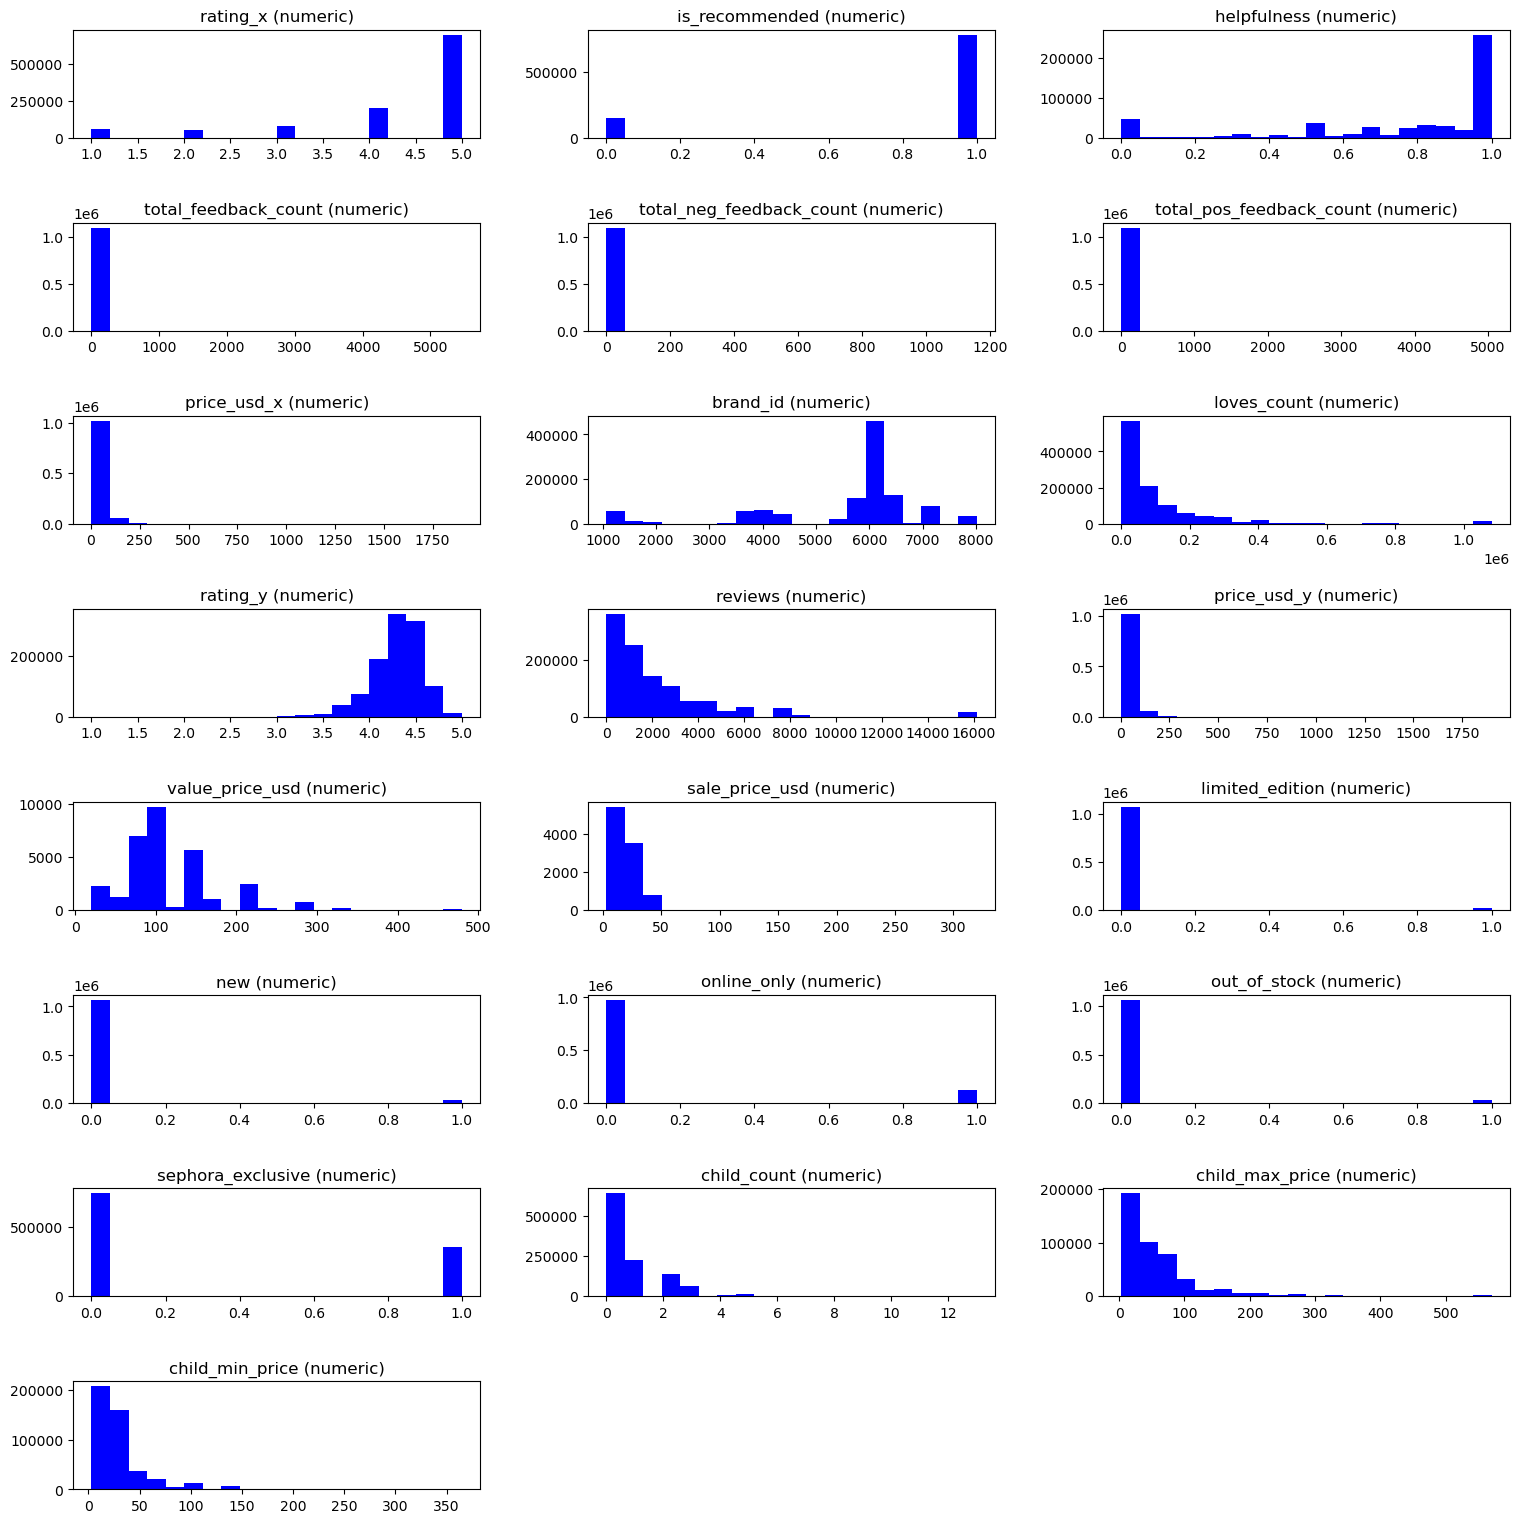

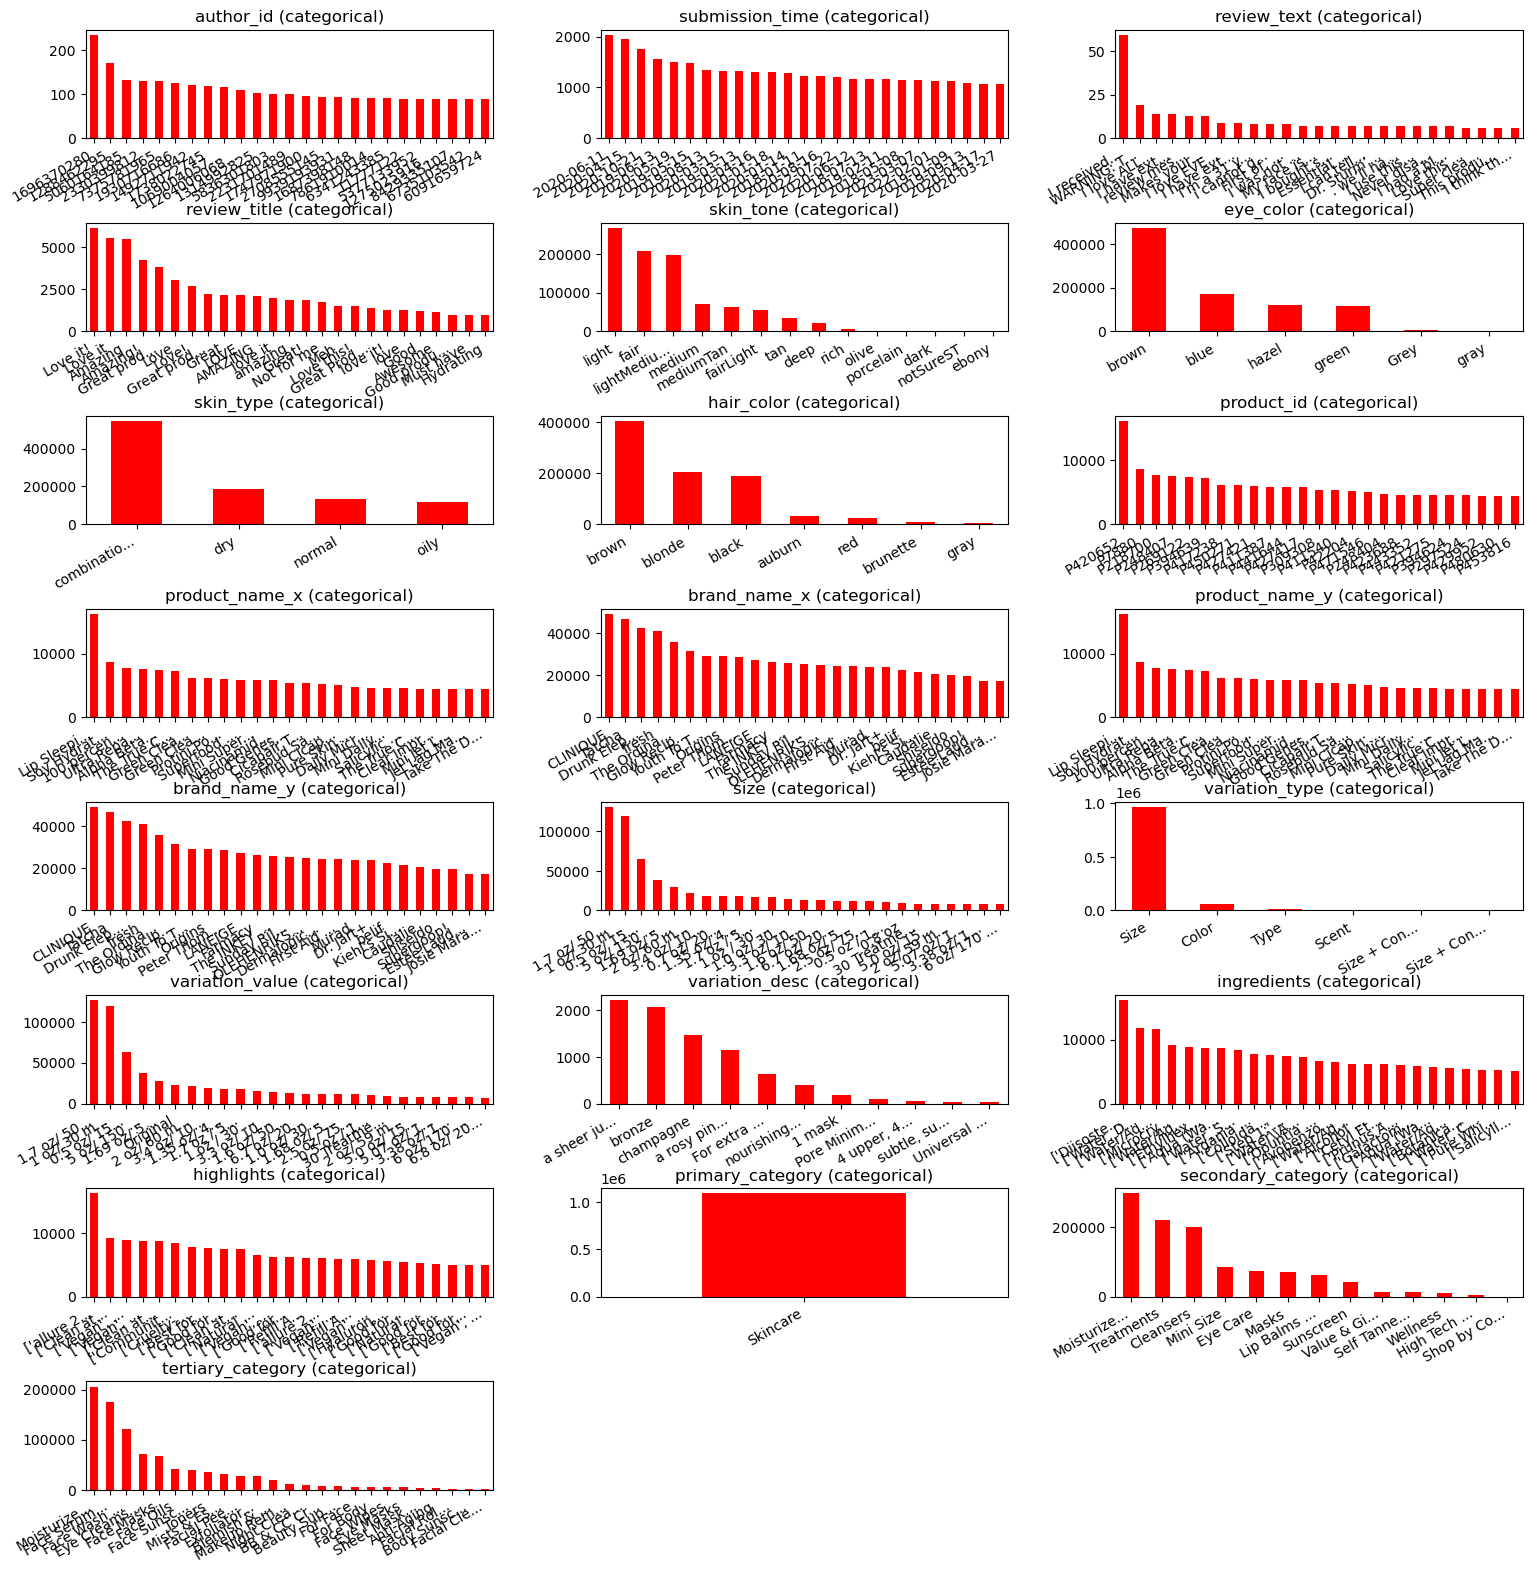

In [20]:
plot_feature_distributions(df)

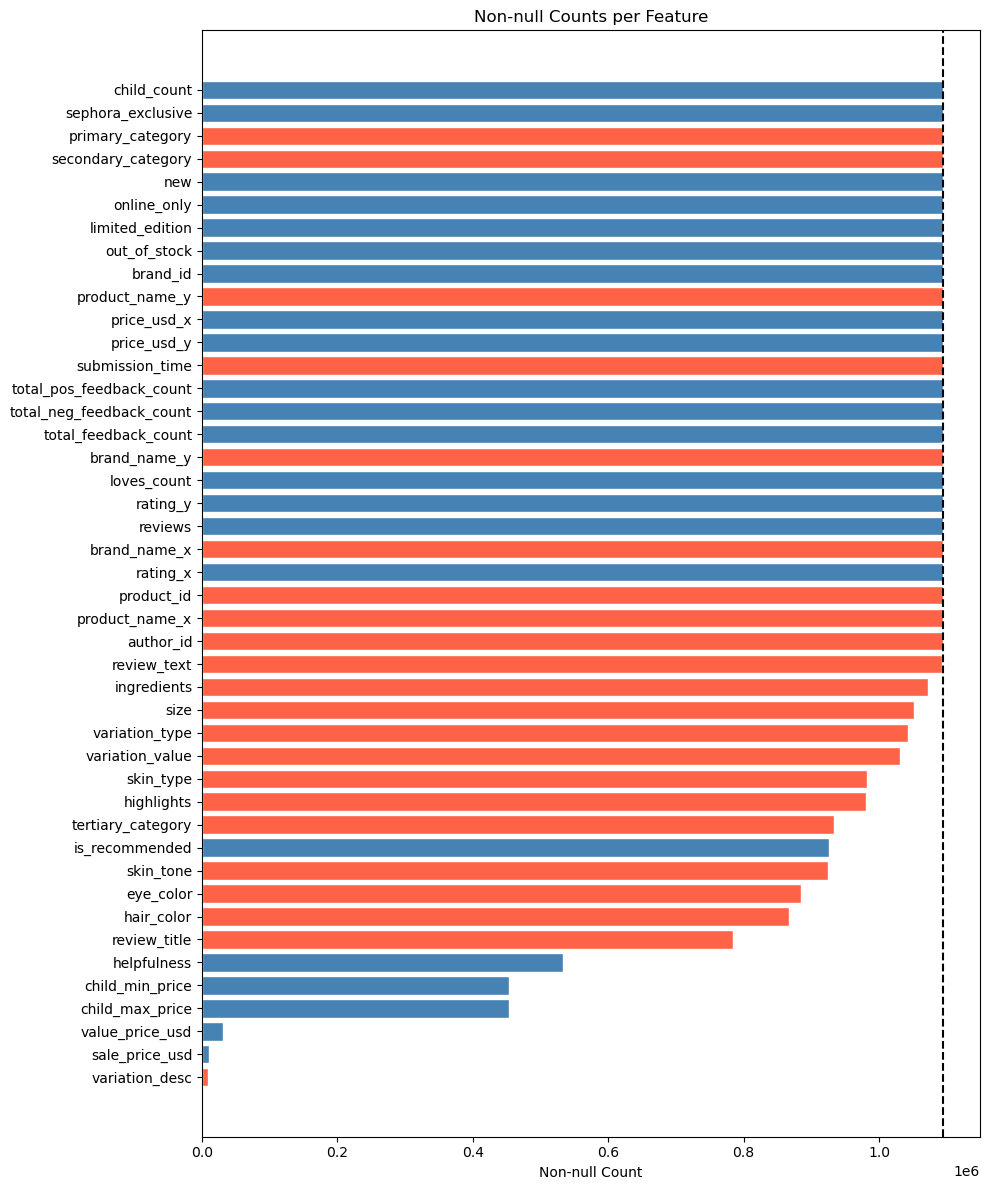

In [21]:
non_null_counts = df.notnull().sum().sort_values()

# classify each feature
numeric_cols = set(df.select_dtypes(include='number').columns)
categorical_cols = set(df.select_dtypes(include=['object', 'category']).columns)

# assign colors based on type
colors = ['tomato' if col in categorical_cols else 'steelblue' for col in non_null_counts.index]

plt.figure(figsize=(10, 12))
bars = plt.barh(non_null_counts.index, non_null_counts.values, color=colors, edgecolor='white')
plt.axvline(x=len(df), color='black', linestyle='--', label='Total rows')
plt.xlabel('Non-null Count')
plt.title('Non-null Counts per Feature')
plt.tight_layout()
plt.show()

## Feature Observations
- Any repeat named column with X is from reviews and Y is from products
    - For example rating_x is rating for review (ordinal ranking from 1-5) and rating_y is rating for products (aggregated avgs)
    - These two are interesting because they are measured differently and provide different signals for our model to learn from, so we don't have to drop either feature

- Other affected features 
    - Categorical: brand_name, product_name | Numeric: price_usd
    - The graphs look virtually identical, so we will proceed to drop the repeat columns for these features from the reviews table (since products would be the single source of truth / authority lv source for these columns)

- Compared the millions of other rows, I feel it might be worth dropping helpfulness, child_min_price, child_max_price, value price, sale price, and variation desc as ~50% of the data is missing 

### Numerical Data
- is_reccomended is our target; clearly our dataset is SEVERELY IMBALANCED since the number of reccomended products (1's) far outnumbers the number of non-reccomendations (0's)
    - for the purposes of this analysis, we will not be dealing with this issue of data imbalance at the data level
    - I will stick with keeping things fair by reweighting the loss at the algorithmic level (penalize mistakes on the minority class proportional to our data split using class_weight='balanced') and then analyzing imbalance at the evaluation level (statified k-fold cv and looking at F1 score & AUC-PR over accuracy and AUC-ROC)
        - WWT have AUC-PR since it focuses on minoirty class performance, doesn't make our imbalanced data look too optimistic; same philosophy for F1 score prioritization

### Categorical Data
Data to drop in general:
- ID's for product, brand, and author are not useful for this analysis
    - same goes for raw timestamps of review submissions
- Review text/title and ingredients are not in the scope of the project as those features need NLP/Sentiment analysis

#### Feature Engineering Methods

Placeholder Imputation: Add unknowns, fill missing values so that features can be encoded 

One Hot Encoding: Creates a new binary column for each unique category
- Because each column is treated as independent, it works best for low-cardinality features; all categories are preserved without assuming order
- This makes the signals more interpretable since we can isolate which part of our categorical data is actually important for making a prediction
    - skin type, hair color, eye color, and variation type (regarding what version of product) would best benefit from this
    - don't want to use OHE on too many variables, lest we explode our features (unnessecary dimensionality) and slow our training down too much

Target Encoding: Replaces each category with the mean of the target variable representing how much that feature leads to a positive outcome
- Cardinality does not matter here; so we can apply this method to high-cardinality features to create more compact representations that are powerful for tree based methods
    - Essentially, for something like brand_name, it takes 200 unique brands and puts it into one value that allows for 1 split threshold as opposed to doubling the amount of columns/splits needed to learn
- Compute target encoding on the training, and apply to test (but dont fit) - avoid leakages where info from our test set is used during training to fit our models
    - Rest of the features not listed in OHE will be target encoded

What happens without OHE or Target Encoding?
- Without OHE, we might not, for instance, pick up a signal that oily skin types reccomend products differently than dry skin types...
- Worse model performance (more noise, less accuracy/interpretability), slower training, less structure that is hidden in our raw data would be exposed

### *Addendum: From Modeling to Feature Engineering
After making our basic decision tree, I saw a 97% F1 score which was suspiciously indicative of data leakage issues. 
- Upon doing a feature importance inspection, `ratings_x`, `total_neg/pos_feedback_count`, and `total_feedback_count` actually did need to be deleted (99% and 57-67% feature importance respectively)
    - This makes sense since good ratings artificially correlate to reccomendations; we shouldn't logically be using these features to make predictions because they are made post-hoc in relation to reccs.
- As far as other feature importance issues go, I am aware that the feature product_name_y (20%) is where a circularity occurs because the model is learning to predict based on historical means. Methods like LOO Encoding exist to remedy this; the same goes for using SMOTE for class imbalance issues, but these techniques are noted for future work. 

![With no removals of features](images\ft_importance1.png)

![With just ratings_x removed](images\ft_importance2.png)

<class 'pandas.core.frame.DataFrame'>
Index: 926423 entries, 0 to 1094410
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   is_recommended      926423 non-null  float64
 1   skin_tone           885943 non-null  object 
 2   eye_color           884111 non-null  object 
 3   skin_type           907355 non-null  object 
 4   hair_color          867643 non-null  object 
 5   product_name_y      926423 non-null  object 
 6   brand_name_y        926423 non-null  object 
 7   loves_count         926423 non-null  int64  
 8   rating_y            926423 non-null  float64
 9   reviews             926423 non-null  float64
 10  size                885660 non-null  object 
 11  variation_type      881791 non-null  object 
 12  variation_value     871516 non-null  object 
 13  price_usd_y         926423 non-null  float64
 14  limited_edition     926423 non-null  int64  
 15  new                 926423 non-null  i

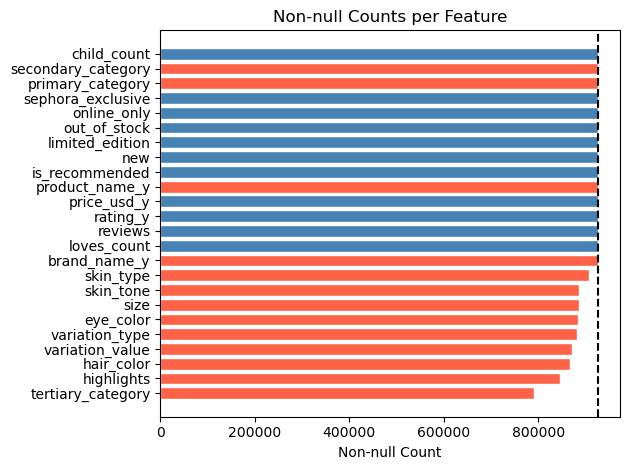

In [22]:
# Making our new data stores

# useless signals: author_id, product_id, brand_id, submission_time, review_title, review_text, ingredients
# repeats: product_name_x, brand_name_x, price_usd_x
# from missing values: variation_desc, sale_price_usd, value_price_usd, child_max_price, child_min_price, helpfulness
# artificially predictive features: rating_x

# print(df.columns.tolist())
cols_to_drop = [
    'author_id', 'product_id', 'brand_id', 'submission_time', 'review_title', 'review_text', 'ingredients', # useless signals
    'product_name_x', 'brand_name_x', 'price_usd_x', # repeats
    'variation_desc', 'sale_price_usd', 'value_price_usd', 'child_max_price', 'child_min_price', 'helpfulness', # missing values
    'rating_x', 'total_neg_feedback_count', 'total_feedback_count', 'total_pos_feedback_count' # leakage - addendum
]

df_clean = df.drop(columns=cols_to_drop)
df_clean.dropna(subset=['is_recommended'], inplace=True) 
df_clean

df_clean.info()

non_null_counts = df_clean.notnull().sum().sort_values()
numeric_cols = set(df_clean.select_dtypes(include='number').columns)
categorical_cols = set(df_clean.select_dtypes(include=['object', 'category']).columns)
colors = ['tomato' if col in categorical_cols else 'steelblue' for col in non_null_counts.index]
bars = plt.barh(non_null_counts.index, non_null_counts.values, color=colors, edgecolor='white')
plt.axvline(x=len(df_clean), color='black', linestyle='--', label='Total rows')
plt.xlabel('Non-null Count')
plt.title('Non-null Counts per Feature')
plt.tight_layout()
plt.show()

In [23]:
# split the features and label data
dfc = df_clean.copy()
dfc_features = dfc.drop(columns=['is_recommended'])
dfc_target = dfc['is_recommended']

dfc_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 926423 entries, 0 to 1094410
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   skin_tone           885943 non-null  object 
 1   eye_color           884111 non-null  object 
 2   skin_type           907355 non-null  object 
 3   hair_color          867643 non-null  object 
 4   product_name_y      926423 non-null  object 
 5   brand_name_y        926423 non-null  object 
 6   loves_count         926423 non-null  int64  
 7   rating_y            926423 non-null  float64
 8   reviews             926423 non-null  float64
 9   size                885660 non-null  object 
 10  variation_type      881791 non-null  object 
 11  variation_value     871516 non-null  object 
 12  price_usd_y         926423 non-null  float64
 13  limited_edition     926423 non-null  int64  
 14  new                 926423 non-null  int64  
 15  online_only         926423 non-null  i

In [24]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    dfc_features, dfc_target,
    test_size=0.3,
    random_state=SEED,
    stratify=dfc_target
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (648496, 23), Test: (277927, 23)


In [25]:
# Apply data transformations / hybrid encoding to categorical variables.
# Placeholder imputation
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    X_train[col] = X_train[col].fillna('Unknown')
    X_test[col] = X_test[col].fillna('Unknown')
# Missingness flag - approach not used here but could be useful for a more extensive analysis at a later date
# # Construct new features (e.g., ratios, age groups, spending levels).
# categorical_cols = ["skin_type", "hair_color", "eye_color", "variation_type"]
# def add_placeholder_indicators(df, cols, placeholders):
#     for col in cols:
#         indicator = f"{col}_placeholder"
#         df[indicator] = df[col].isin(placeholders).astype(int)
#         # place the indicator right after the source column
#         cols_list = df.columns.tolist()
#         # remove indicator and insert after its source column
#         cols_list.insert(cols_list.index(col) + 1, cols_list.pop(cols_list.index(indicator)))
#         df = df[cols_list]
#     return df
# df = add_placeholder_indicators(df, categorical_cols, placeholders)
# df

# define encoding groups
ohe_cols = ['skin_type', 'hair_color', 'eye_color', 'variation_type']
remaining_cat_cols = [col for col in X_train.select_dtypes(include=['object', 'category']).columns
                      if col not in ohe_cols]

# OHE and Target Encoding — fit on training data only to prevent data leakage
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[ohe_cols])
te = TargetEncoder(cols=remaining_cat_cols)
te.fit(X_train, y_train) # needs y train since you need to compute the target means for each category

# apply the transformations and concatenate the encoding results for our train and test set
X_train = pd.concat([
    te.transform(X_train).drop(columns=ohe_cols),
    pd.DataFrame(ohe.transform(X_train[ohe_cols]), columns=ohe.get_feature_names_out(ohe_cols), index=X_train.index)
], axis=1)

X_test = pd.concat([
    te.transform(X_test).drop(columns=ohe_cols),
    pd.DataFrame(ohe.transform(X_test[ohe_cols]), columns=ohe.get_feature_names_out(ohe_cols), index=X_test.index)
], axis=1)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (648496, 46), Test: (277927, 46)


Note: 46 cols after feature encoding-- makes sense when I stored the dt model at the end.

In [26]:
# # use stratified k-folds cross validation; may take more resources but is robust
from sklearn.model_selection import StratifiedKFold, cross_validate
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) # shuffle randomizes order of samples

In [27]:
# a. Train a DecisionTreeClassifier using Gini impurity.
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=SEED)

# b. Tune max_depth, min_samples_split, and ccp_alpha (pre-pruning).
# use grid search for a more exhaustive search if resources allow
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 7, 10, 15], # upper bound of splits from root to leaf; set lower than default to speed up training and make sure that trees don't grow too deep
    'min_samples_split': [100, 250, 500, 750], # lower bound of samples for required split; set higher for this dataset to prevent overfitting
    'ccp_alpha': [0, 0.0001, 0.001, 0.01] # pruning aggresiveness; need smaller pruning values for this dataset to prevent underfitting
}
# random_search = RandomizedSearchCV(estimator=dt, param_distributions=param_grid, cv=skf, scoring='f1', n_jobs=-1, random_state=SEED)
# random_search.fit(X_train, y_train)
grid_search = GridSearchCV(dt, param_grid, cv=skf, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)


# c. Evaluate train and test F1 score
from sklearn.metrics import f1_score
best_tree = grid_search.best_estimator_
f1_train = f1_score(y_train, best_tree.predict(X_train))
f1_test = f1_score(y_test, best_tree.predict(X_test))

best_params = grid_search.best_params_
print("\nBest Decision Tree Parameters:")
print(f"max_depth: {best_params['max_depth']}, min_samples_split: {best_params['min_samples_split']}, ccp_alpha: {best_params['ccp_alpha']}")

best_cv_score = grid_search.best_score_
print(f"\nBest CV (Fold) F1: {best_cv_score:.4f}")
print(f"Train F1: {f1_train:.4f}")
print(f"Test F1: {f1_test:.4f}")


Best Decision Tree Parameters:
max_depth: 10, min_samples_split: 750, ccp_alpha: 0

Best CV (Fold) F1: 0.7288
Train F1: 0.7213
Test F1: 0.7160


In [28]:
importances = pd.Series(best_tree.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False).head(10))

product_name_y        0.893209
rating_y              0.038970
skin_tone             0.009663
reviews               0.008931
hair_color_Unknown    0.007246
eye_color_Unknown     0.004269
loves_count           0.004182
highlights            0.004090
brand_name_y          0.003427
size                  0.003052
dtype: float64


In [29]:
# eval by most accurate folds from our data
results_df = pd.DataFrame(grid_search.cv_results_)
score_table = results_df[[
        'param_max_depth',
        'param_min_samples_split',
        'param_ccp_alpha',
        'mean_test_score', # avg accuracy across the stratified k-folds
        'std_test_score' # how heavily scores are dependent on which folds are used for validation
    ]].sort_values('mean_test_score', ascending=False)

score_table

,param_max_depth,param_min_samples_split,param_ccp_alpha,mean_test_score,std_test_score
11,10,750,0.00,0.728792,0.010025
10,10,500,0.00,0.728161,0.009703
9,10,250,0.00,0.727521,0.010179
8,10,100,0.00,0.727233,0.009976
7,7,750,0.00,0.723490,0.008366
...,...,...,...,...,...
59,10,750,0.01,0.695875,0.005047
60,15,100,0.01,0.695875,0.005047
61,15,250,0.01,0.695875,0.005047
62,15,500,0.01,0.695875,0.005047


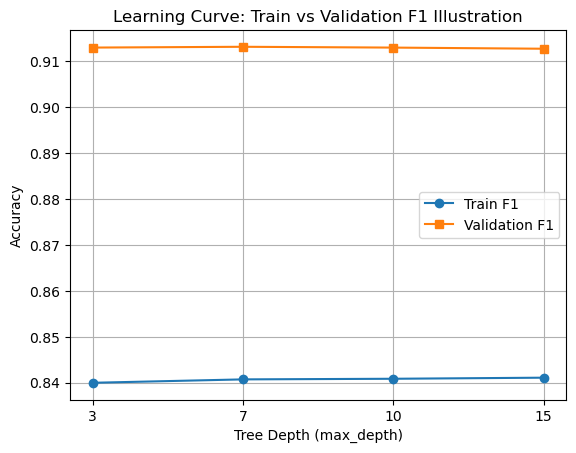

In [30]:
from sklearn.model_selection import cross_val_score
depth = param_grid['max_depth']
train_scores = []
val_scores = []

# hold the best params from our previous search constant
# fit on a curve that looks at our depths
for d in depth:
    clf = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        min_samples_split=best_params['min_samples_split'],
        ccp_alpha=best_params['ccp_alpha'],
        random_state=0
    )
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    val_score = cross_val_score(clf, X_train, y_train, cv=skf, scoring='f1').mean()
    val_scores.append(val_score)

# d. Plot the learning curve to show how training and validation scores change with depth.
depth_labels = [str(d) if d is not None else 'None' for d in depth]
plt.plot(depth_labels, train_scores, marker='o', label='Train F1')
plt.plot(depth_labels, val_scores, marker='s', label='Validation F1')
# plt.plot(depth, train_scores, label='Train accuracy')
# plt.plot(depth, val_scores, label='Validation accuracy')
plt.xlabel('Tree Depth (max_depth)')
plt.ylabel('Accuracy')
plt.title('Learning Curve: Train vs Validation F1 Illustration')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# general metrics plotting fxn; pulled from Columbia code
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
def evaluate_classifier(model, X_test, y_test, classes=None, model_name=None, feature_names=None, top_n=10):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = None

    # accuracy and classification report
    acc = accuracy_score(y_test, y_pred)
    print(f'\n{model_name or "Model"} Accuracy: {acc:.4f}\n')
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    if classes is None:
        classes = np.unique(y_test)
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))  # 2x2 grid
    ax = axes[0, 0]
    im = ax.imshow(cm, interpolation='nearest', cmap='viridis')
    ax.set_title(f'{model_name or "Model"} Confusion Matrix')
    ax.set_xticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(classes)))
    ax.set_yticklabels(classes)
    for i in range(cm.shape[0]):
      for j in range(cm.shape[1]):
          txt = ax.text(j, i, cm[i, j], ha='center', va='center', color='skyblue')
          txt.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground='black'),
                              path_effects.Normal()])
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

    # AUCROC
    if len(np.unique(y_test)) == 2 and y_score is not None:
        ax = axes[0, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=1)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
        ax.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title('ROC Curve')
        ax.legend(loc='lower right')
    # AUCPR
        ax = axes[1, 0]
        precision, recall, _ = precision_recall_curve(y_test, y_score)
        pr_auc = auc(recall, precision)
        positive_ratio = np.mean(y_test)
        ax.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.2f})')
        ax.hlines(positive_ratio, 0, 1, colors='red', linestyles='--', label=f'Baseline AUCPR = {positive_ratio:.2f}')
        ax.plot([0, 1], [1, 1], color='green', lw=2, label='Perfect AUCPR = 1')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title('Precision-Recall Curve')
        ax.legend(loc='lower left')
    else:
        axes[0, 1].axis("off")
        axes[1, 0].axis("off")

    # feature importance graph
    ax = axes[1, 1]
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        if feature_names is None:
            feature_names = [f"Feature {i}" for i in range(len(importances))]
        feature_names = np.array(feature_names)
        sorted_idx = np.argsort(importances)[::-1]
        n = min(top_n, len(importances))
        ax.bar(range(n), importances[sorted_idx][:n], tick_label=feature_names[sorted_idx][:n])
        ax.set_xticklabels(feature_names[sorted_idx][:n], rotation=45, ha='right', fontsize=9)
        ax.set_title(f'Top {n} Most Important Features')
        ax.set_ylabel('Importance')
        ax.set_xlabel('Feature')
    else:
        ax.text(0.5, 0.5, "No feature_importances_", ha='center', va='center', fontsize=15)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


DecisionTree Accuracy: 0.6033

Classification Report:
               precision    recall  f1-score   support

         0.0       0.23      0.64      0.34     44479
         1.0       0.90      0.60      0.72    233448

    accuracy                           0.60    277927
   macro avg       0.57      0.62      0.53    277927
weighted avg       0.79      0.60      0.66    277927



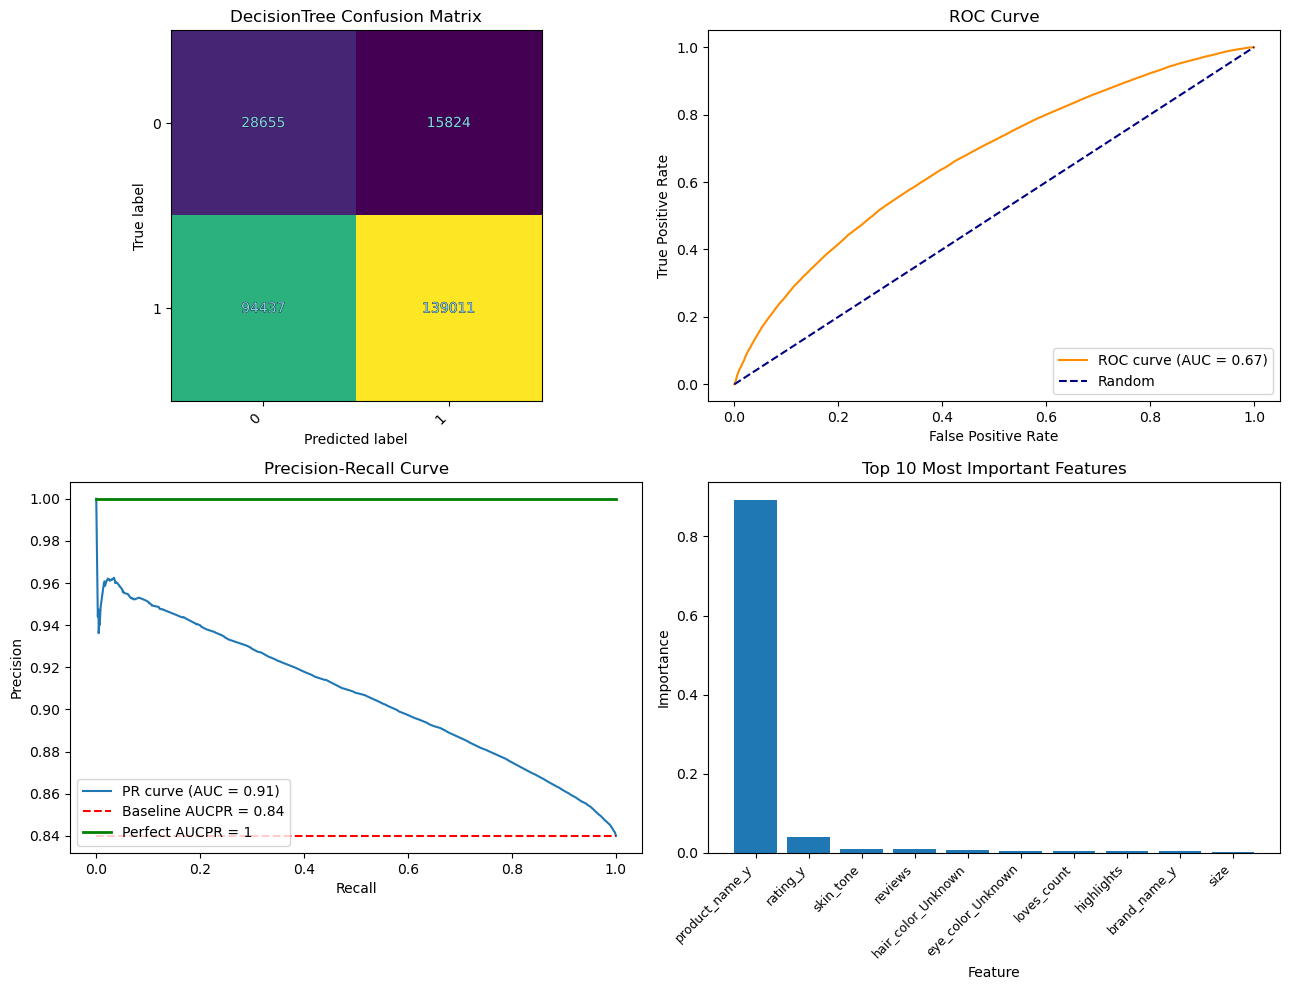

In [34]:
#  Metrics: Accuracy, Precision, Recall, F1, AUCPR
import matplotlib.patheffects as path_effects
evaluate_classifier(best_tree, X_test, y_test, classes=[0, 1], model_name="DecisionTree", feature_names=X_test.columns, top_n=10)

- From Learning Curve: Train F1 stays flat around 0.84 across all depths while Validation F1 stays flat around 0.91. The two lines run parallel rather than diverging, which suggests the model is not meaningfully overfitting or underfitting as depth increases. The consistent gap between train and validation is likely an artifact of class_weight='balanced' affecting how scores are computed on the full training set vs. held-out folds.

- From Metrics and Plotting:
  - Accuracy: 60.3% - intentionally suppressed by class_weight='balanced'; not our primary evaluation metric here
  - Recall (class 1): 0.60 - the majority class recall dropped as expected from the balancing tradeoff
  - F1 Score (class 1): 0.72 weighted - reasonable baseline given the class imbalance and the deliberate algorithmic tradeoff
  - ROC Curve: AUC of 0.67 - the model has moderate ability to separate recommendations from non-recommendations; well above random (0.50) but leaves clear room for improvement with ensemble methods
  - PR Curve: AUC of 0.91 against a baseline of 0.84; this is a meaningful improvement over the no-skill baseline given how imbalanced the classes are; precision stays high above 0.90 until recall pushes past ~0.6, at which point it drops off as the model begins misclassifying majority class examples
  - Feature Importance: product_name_y (89%), rating_y (4%), skin_tone (1%), and reviews (0.9%) were among the more significant top ten features
    - product_name_y dominating at 89% reflects that a product's historical recommendation rate is the strongest predictor of future recommendations; this makes sense given that Sephora shoppers largely buy products with established reputations. At the same time it raises questions about if this is a signal that I want to keep for the future...
    - Reviewer demographic features (skin_tone, hair_color_Unknown, eye_color_Unknown) appear in the top 10 but with very low importance, suggesting product identity matters far more than who is reviewing
    - The appearance of Unknown-encoded OHE features suggests missingness itself carries some weak signal; reviewers who didn't disclose demographics may behave differently on average

# Save Model for Future Reference

In [48]:
import joblib

# save and reload the best tree model for future use without retraining
joblib.dump(best_tree, 'models/best_tree.pkl')
best_tree = joblib.load('models/best_tree.pkl')

print("Model type:", type(best_tree))
print("Parameters:", best_tree.get_params())
print("Feature count:", best_tree.n_features_in_)

Model type: <class 'sklearn.tree._classes.DecisionTreeClassifier'>
Parameters: {'ccp_alpha': 0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 750, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 0, 'splitter': 'best'}
Feature count: 46


## Baseline Model Evaluation and Visualization
- Feeding in the stratified k-Folds to the gridsearch had a meaningful impact on the performance of our decision tree; best parameters landed at max_depth=10, min_samples_split=750, ccp_alpha=0
- With a CV F1 of 0.7288, Train F1 of 0.7213, and Test F1 of 0.7160, the model is generalizing well with no signs of overfitting; the tight gap between train and test is expected given the large dataset size
  - ccp_alpha=0 in the best parameters means no pruning was applied; the tree grows to its full allowed depth which is appropriate here since pruning consistently hurt performance in our grid
  - class_weight='balanced' intentionally tanks overall accuracy (60%) in exchange for better minority class detection; this is the algorithmic-level imbalance intervention noted in the feature observations section. Originally, the accuracy was something like 70% without the additional field

Relevant metrics:
- F1 Score (class 0): 0.23 weighted - mislabled too many good products as bad; ensemble models may improve on this metric
  - Precision (class 0): 0.23 - of all predicted non-recommendations, 23% were correct; the model casts a wide net for the minority class
  - Recall (class 0): 0.64 - the model correctly identifies 64% of actual non-recommendations, a meaningful improvement over an unweighted tree

# Ensemble Methods

Now we will use XGBoost and LightGBM to see if we can improve the F1 score (harmonic mean of Precision and Recall) for the minority class. 

In [ ]:
# Install and use XGBoostClassifier (xgboost library).
# Perform similar tuning and visualize:
# ● training vs. validation loss (using eval_set or early stopping)
# ● feature importance (plot_importance)
# ● effect of learning rate and tree depth on bias-variance balance
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance
# Parameter grid for search
param_distr = {
    'learning_rate': [0.01, 0.1, 0.3], # given rates; how new trees self-correct
    'n_estimators': [50, 100, 150, 200], # mumber of boosting stages / trees in the ensemble
    'max_depth': [4, 6, 8, 10], # omit 2 and none; won't be fruitful
    'subsample': [0.75] # fraction to sample without replacement
}
le = LabelEncoder()
y_train_numeric = le.fit_transform(y_train)
y_test_numeric = le.transform(y_test)
# binary classification problem, use auc since our data is imbalanced
xgb_model = XGBClassifier(objective='binary:logistic', random_state=0, eval_metric='auc')
random_search = RandomizedSearchCV(xgb_model, param_distributions=param_distr, n_iter=4, cv=skf, n_jobs=-1, random_state=0)
random_search.fit(X_train, y_train_numeric)
best_xgb = random_search.best_estimator_
print("\nBest XGBoost Parameters (RandomizedSearchCV):")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nBest CV (Fold) accuracy: {random_search.best_score_:.4f}")
print(f"Train accuracy: {best_xgb.score(X_train, y_train_numeric):.4f}")
print(f"Test accuracy: {best_xgb.score(X_test, y_test_numeric):.4f}")

# Plans of Action
1. add the website version and decompose the notebook
2. review codebase and remove the product_name_y
3. add SHAP values to contextualize our DT-based models' results

